# 📊 Deepfake Detection — SHAP Report
### Yeh notebook batayegi — Model ne FAKE kyun kaha?
---

## Step 1 — Libraries Import

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'shap', 'reportlab'], check=True)

CompletedProcess(args=['pip', 'install', 'shap', 'reportlab'], returncode=0)

In [2]:
!pip install shap reportlab

In [3]:
import os
import numpy as np
import librosa
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries load ho gayi!')

✅ Libraries load ho gayi!


## Step 2 — Pehle Wala Model Dobara Train Karo

In [4]:
REAL_FOLDER = r'D:\Hamza\NIAI\NIAI_Project\DeepfakeProject\dataset\real_cleaned'
FAKE_FOLDER = r'D:\Hamza\NIAI\NIAI_Project\DeepfakeProject\dataset\fake'
REPORT_PATH = r'D:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\deepfake_report.pdf'
CHARTS_PATH = r'D:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\charts'

os.makedirs(CHARTS_PATH, exist_ok=True)

def extract_mfcc(file_path, n_mfcc=40):
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc, axis=1), audio, sr
    except:
        return None, None, None

# Dataset load karo
X, y = [], []
real_files = sorted(os.listdir(REAL_FOLDER))
fake_files = sorted(os.listdir(FAKE_FOLDER))

for f in real_files:
    feat, _, _ = extract_mfcc(os.path.join(REAL_FOLDER, f))
    if feat is not None:
        X.append(feat); y.append(0)

for f in fake_files:
    feat, _, _ = extract_mfcc(os.path.join(FAKE_FOLDER, f))
    if feat is not None:
        X.append(feat); y.append(1)

X = np.array(X)
y = np.array(y)

# Train karo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

print(f'✅ Model trained! Total samples: {len(X)}')

✅ Model trained! Total samples: 204


## Step 3 — Audio Analyze Karo (Chunking + SHAP)

In [5]:
def analyze_audio(file_path):
    """
    1 minute tak ki audio analyze karo:
    - Har 3 sec chunk ka result
    - SHAP se kyun fake/real
    - Timeline chart
    """
    print(f'\n🔍 Analyzing: {os.path.basename(file_path)}')
    
    # Load full audio
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
    except Exception as e:
        print(f'❌ Error: {e}')
        return None
    
    chunk_size = 3 * sr  # 3 seconds
    total_chunks = len(audio) // chunk_size
    
    if total_chunks == 0:
        # Short audio — single prediction
        total_chunks = 1
        audio = np.pad(audio, (0, chunk_size - len(audio)))
    
    results = []
    
    for i in range(total_chunks):
        start = i * chunk_size
        end   = start + chunk_size
        chunk = audio[start:end]
        
        # MFCC extract
        mfcc = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=40)
        feat = np.mean(mfcc, axis=1).reshape(1, -1)
        feat_scaled = scaler.transform(feat)
        
        # Predict
        pred = model.predict(feat_scaled)[0]
        prob = model.predict_proba(feat_scaled)[0]
        
        results.append({
            'chunk'     : i + 1,
            'start_sec' : i * 3,
            'end_sec'   : (i + 1) * 3,
            'label'     : 'FAKE' if pred == 1 else 'REAL',
            'confidence': prob[pred] * 100,
            'features'  : feat_scaled[0]
        })
    
    # Final vote
    fake_count = sum(1 for r in results if r['label'] == 'FAKE')
    real_count = len(results) - fake_count
    final = 'FAKE' if fake_count > real_count else 'REAL'
    avg_conf = np.mean([r['confidence'] for r in results])
    
    print(f'\n{'='*45}')
    print(f'  FINAL RESULT: {"🔴 FAKE" if final=="FAKE" else "🟢 REAL"}')
    print(f'  Confidence  : {avg_conf:.1f}%')
    print(f'  Chunks      : {real_count} REAL | {fake_count} FAKE')
    print(f'{'='*45}')
    
    return results, final, avg_conf

print('✅ Analysis function ready!')

✅ Analysis function ready!


## Step 4 — SHAP Chart Banao

In [6]:
def generate_shap_chart(results, filename):
    """SHAP feature importance chart"""
    
    explainer = shap.TreeExplainer(model)
    
    fake_chunks = [r for r in results if r['label'] == 'FAKE']
    if not fake_chunks:
        fake_chunks = results
    
    most_suspicious = max(fake_chunks, key=lambda x: x['confidence'])
    feat = most_suspicious['features'].reshape(1, -1)
    
    shap_values = explainer.shap_values(feat)
    
    feature_names = [f'MFCC_{i+1}' for i in range(40)]
    
    # SHAP values ko flat array mein convert karo
    if isinstance(shap_values, list):
        vals = np.array(shap_values[1]).flatten()
    else:
        vals = np.array(shap_values).flatten()
    
    # Sirf 40 values lo
    vals = vals[:40]
    
    # Top 15 indices
    top_idx  = np.argsort(np.abs(vals))[-15:]
    top_vals = [float(vals[i]) for i in top_idx]
    top_names = [feature_names[i] for i in top_idx]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_vals]
    ax.barh(top_names, top_vals, color=colors_bar)
    
    ax.set_xlabel('SHAP Value (Positive = Fake indicator)')
    ax.set_title('Kyun FAKE Hai? — Top Contributing Features')
    ax.axvline(x=0, color='black', linewidth=0.8)
    
    red_patch   = mpatches.Patch(color='#e74c3c', label='FAKE ki taraf')
    green_patch = mpatches.Patch(color='#2ecc71', label='REAL ki taraf')
    ax.legend(handles=[red_patch, green_patch])
    
    plt.tight_layout()
    chart_path = os.path.join(CHARTS_PATH, f'shap_{filename}.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ SHAP chart saved!')
    return chart_path

print('✅ SHAP chart function ready!')

✅ SHAP chart function ready!


## Step 5 — Timeline Chart Banao

In [7]:
def generate_timeline_chart(results, filename):
    """Konse second mein fakeness zyada hai"""
    
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for r in results:
        color = '#e74c3c' if r['label'] == 'FAKE' else '#2ecc71'
        ax.barh(
            y=0,
            width=3,
            left=r['start_sec'],
            color=color,
            alpha=0.8,
            height=0.5
        )
        ax.text(
            r['start_sec'] + 1.5, 0,
            f"{r['confidence']:.0f}%",
            ha='center', va='center',
            fontsize=8, color='white', fontweight='bold'
        )
    
    ax.set_xlabel('Time (seconds)')
    ax.set_title('Timeline — Kahan Fakeness Hai?')
    ax.set_yticks([])
    
    red_patch   = mpatches.Patch(color='#e74c3c', label='FAKE')
    green_patch = mpatches.Patch(color='#2ecc71', label='REAL')
    ax.legend(handles=[red_patch, green_patch])
    
    plt.tight_layout()
    chart_path = os.path.join(CHARTS_PATH, f'timeline_{filename}.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Timeline chart saved!')
    return chart_path

print('✅ Timeline function ready!')

✅ Timeline function ready!


## Step 6 — PDF Report Generate Karo

In [8]:
def generate_pdf_report(file_path, results, final, avg_conf, shap_chart, timeline_chart):
    """Complete PDF report banao"""
    
    doc    = SimpleDocTemplate(REPORT_PATH, pagesize=A4)
    styles = getSampleStyleSheet()
    story  = []
    
    # Title
    story.append(Paragraph('Deepfake Voice Detection Report', styles['Title']))
    story.append(Paragraph('Pakistani Urdu-English Mixed Audio Analysis', styles['Normal']))
    story.append(Spacer(1, 0.3*inch))
    
    # File Info
    story.append(Paragraph('Audio File Information', styles['Heading2']))
    fake_count = sum(1 for r in results if r['label'] == 'FAKE')
    real_count = len(results) - fake_count
    
    info_data = [
        ['Field', 'Value'],
        ['File Name', os.path.basename(file_path)],
        ['Final Result', f'{"FAKE (AI Generated)" if final=="FAKE" else "REAL (Human Voice)"}'],
        ['Overall Confidence', f'{avg_conf:.1f}%'],
        ['Total Chunks', str(len(results))],
        ['REAL Chunks', str(real_count)],
        ['FAKE Chunks', str(fake_count)],
    ]
    
    t = Table(info_data, colWidths=[2.5*inch, 3.5*inch])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.darkblue),
        ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
        ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.lightgrey]),
        ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
        ('FONTSIZE', (0,0), (-1,-1), 11),
        ('PADDING', (0,0), (-1,-1), 8),
    ]))
    story.append(t)
    story.append(Spacer(1, 0.3*inch))
    
    # Timeline Chart
    story.append(Paragraph('Timeline Analysis — Kahan Fakeness Hai?', styles['Heading2']))
    story.append(Image(timeline_chart, width=6*inch, height=2*inch))
    story.append(Spacer(1, 0.2*inch))
    
    # SHAP Chart
    story.append(Paragraph('Feature Analysis — Kyun FAKE Hai?', styles['Heading2']))
    story.append(Paragraph(
        'Neeche chart mein RED bars FAKE ki taraf indicate karte hain. '
        'Jitna lamba bar, utna zyada suspicious feature.',
        styles['Normal']
    ))
    story.append(Spacer(1, 0.1*inch))
    story.append(Image(shap_chart, width=6*inch, height=3.5*inch))
    story.append(Spacer(1, 0.3*inch))
    
    # Chunk Details
    story.append(Paragraph('Chunk-by-Chunk Details', styles['Heading2']))
    chunk_data = [['Chunk', 'Time', 'Result', 'Confidence']]
    for r in results:
        chunk_data.append([
            str(r['chunk']),
            f"{r['start_sec']}s — {r['end_sec']}s",
            r['label'],
            f"{r['confidence']:.1f}%"
        ])
    
    ct = Table(chunk_data, colWidths=[1*inch, 2*inch, 1.5*inch, 1.5*inch])
    ct.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.darkblue),
        ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
        ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.lightgrey]),
        ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
        ('FONTSIZE', (0,0), (-1,-1), 10),
        ('PADDING', (0,0), (-1,-1), 6),
    ]))
    story.append(ct)
    
    doc.build(story)
    print(f'\n✅ PDF Report saved: {REPORT_PATH}')

print('✅ PDF function ready!')

✅ PDF function ready!


## Step 7 — Apni Audio File Test Karo!


🔍 Analyzing: real_162.wav

  FINAL RESULT: 🟢 REAL
  Confidence  : 60.7%
  Chunks      : 2 REAL | 1 FAKE


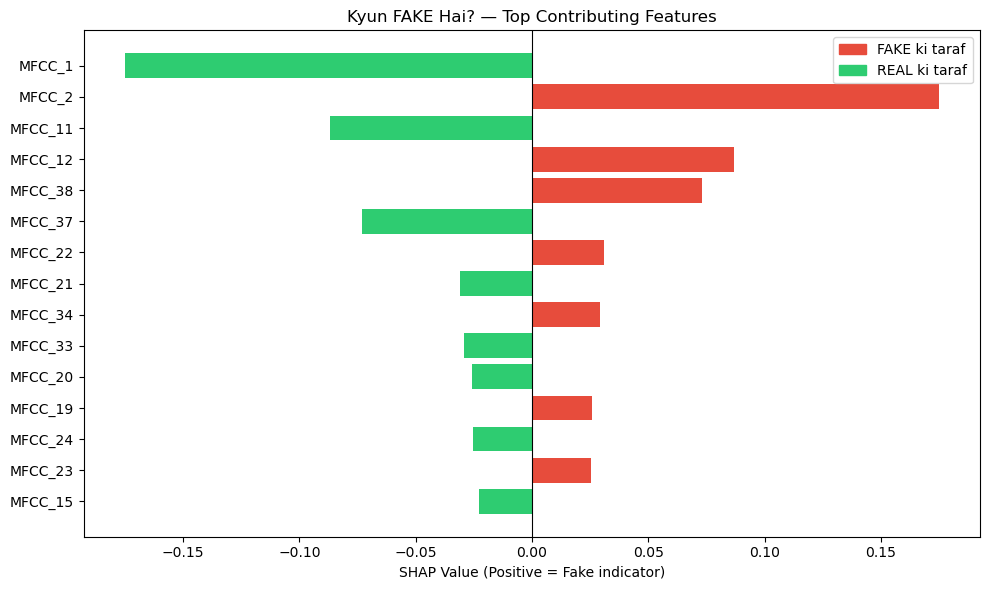

✅ SHAP chart saved!


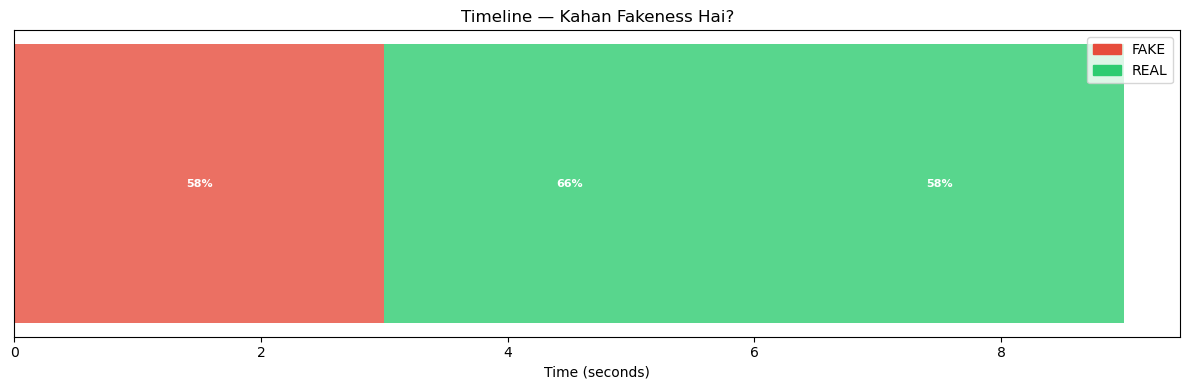

✅ Timeline chart saved!

✅ PDF Report saved: D:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\deepfake_report.pdf

🎉 Complete! Report saved at: D:\Hamza\NIAI\NIAI_Project\deepfake-voice-detection\deepfake_report.pdf


In [9]:
# ← YAHAN APNI FILE KA PATH DALO (fake ya real koi bhi)
TEST_FILE = r'D:\Hamza\NIAI\NIAI_Project\DeepfakeProject\dataset\real\real_162.wav'

# Analyze karo
results, final, avg_conf = analyze_audio(TEST_FILE)

# Charts banao
fname = os.path.splitext(os.path.basename(TEST_FILE))[0]
shap_chart     = generate_shap_chart(results, fname)
timeline_chart = generate_timeline_chart(results, fname)

# PDF report banao
generate_pdf_report(TEST_FILE, results, final, avg_conf, shap_chart, timeline_chart)

print(f'\n🎉 Complete! Report saved at: {REPORT_PATH}')